# Packages

In [2]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


In [ ]:
path_Version = np.load("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/config.npz", allow_pickle=True)['path_Version'].item()
path_Material = np.load("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/config.npz", allow_pickle=True)['path_Material'].item()
path_length = np.load("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/config.npz", allow_pickle=True)['path_length'].item()
num = np.load("/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/config.npz", allow_pickle=True)['num'].item()

print(f"Konfiguration: {path_Version}, {path_Material}, {path_length},\nAnzahl an Files: {num}")

Konfiguration: 4_7e82d44, NoAbsorber, 10cm,
Anzahl an Files:1


In [12]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

# Einzelplots

## NC Energydependent


### In Liquid Xenon

In [18]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.npz"
hist_vals = np.load(path, allow_pickle=True)['hist_vals']
hist_edges = np.load(path, allow_pickle=True)['hist_edges']
hist_pri_vals = np.load(path, allow_pickle=True)['hist_pri_vals']
hist_pri_edges = np.load(path, allow_pickle=True)['hist_pri_edges']

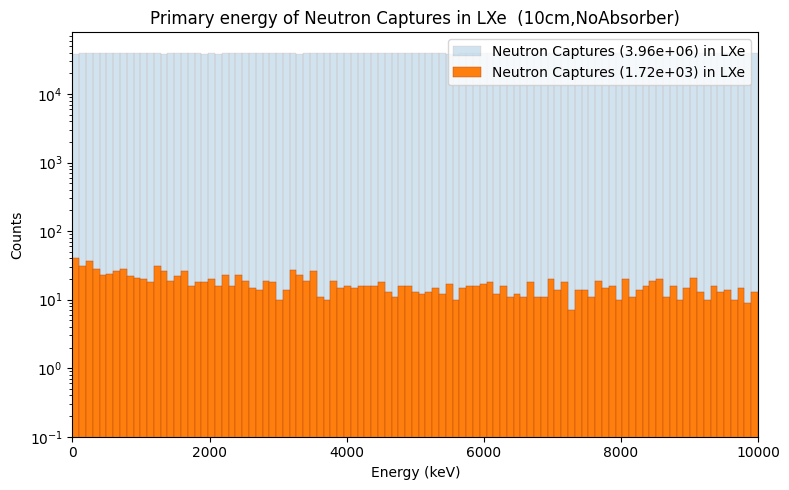

In [19]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe  ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.pdf")
plt.show()

### In Absorber

In [20]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.npz"
hist_vals = np.load(path, allow_pickle=True)['hist_vals']
hist_edges = np.load(path, allow_pickle=True)['hist_edges']
hist_pri_vals = np.load(path, allow_pickle=True)['hist_pri_vals']
hist_pri_edges = np.load(path, allow_pickle=True)['hist_pri_edges']

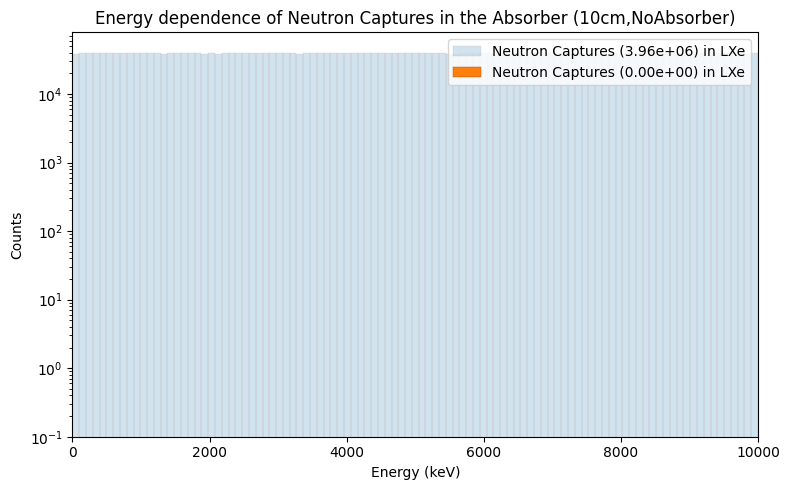

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, hist_pri_vals.max() * 2)
plt.xlim(0, 10000)
plt.title(f'Energy dependence of Neutron Captures in the Absorber ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.pdf" )
plt.show()

## Processes

### Xenon Volume

In [25]:
path = f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Data/{path_Version}/{path_Material}/{path_length}/Processes_LXe.npz"
grouped_data = np.load(path, allow_pickle=True)['grouped_data_values']
index_level0 = np.load(path, allow_pickle=True)['grouped_data_index_level0']
index_level1 = np.load(path, allow_pickle=True)['grouped_data_index_level1']

In [27]:
grouped_data

array([ 15,   1,   1,  31, 568,  15,  38, 592,  43, 245,  86,  79,  11])

/tmp/slurm_bkoberg.33143334/ipykernel_2079137/2158859397.py:32: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.yscale("log")


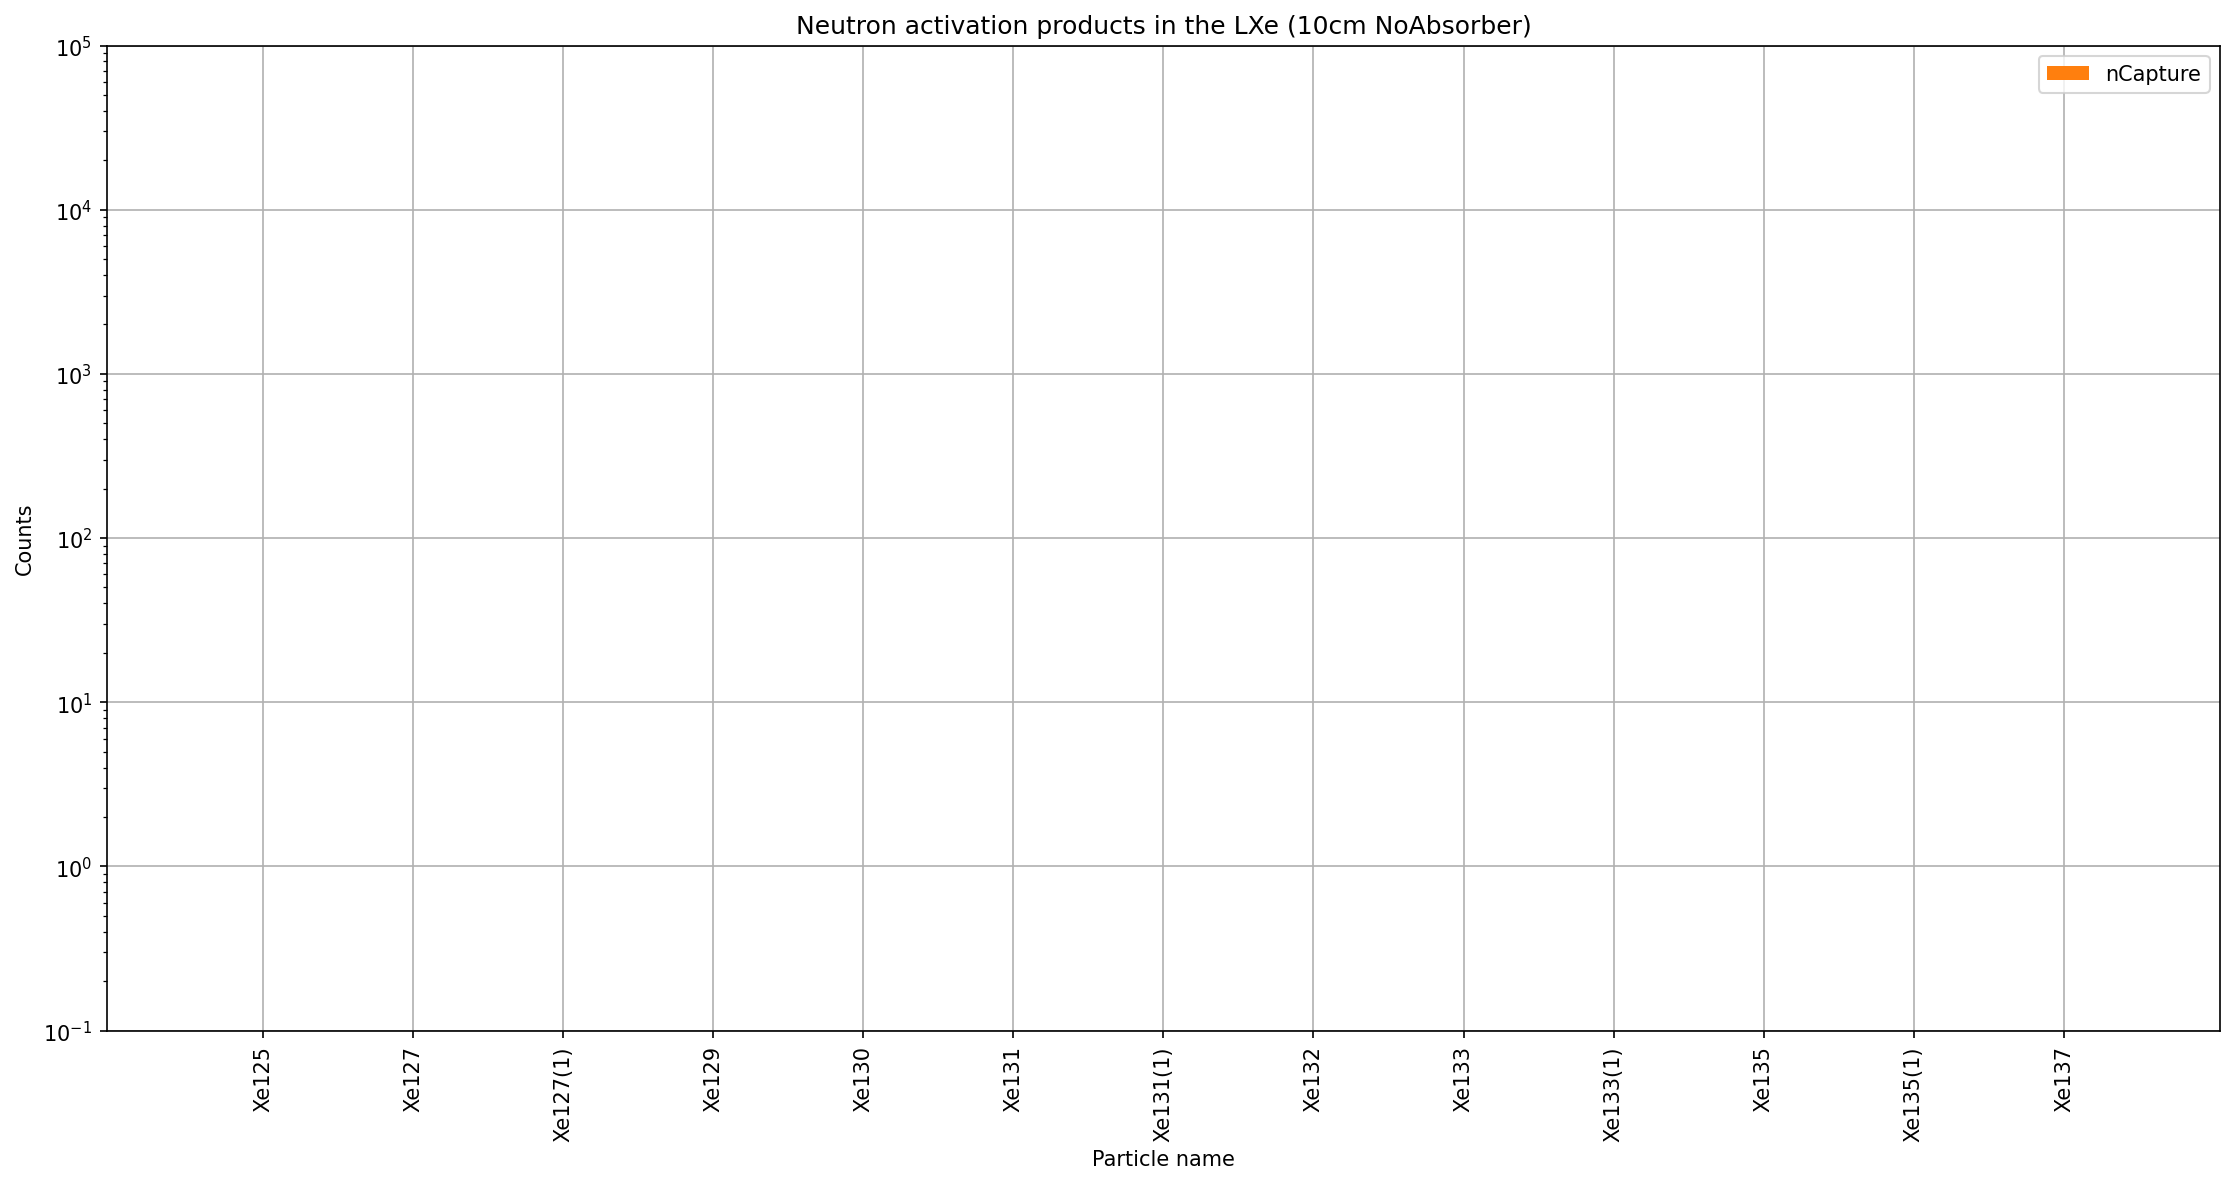

In [26]:
_data = grouped_data#[grouped_data.values > 40]

_particles = np.unique(index_level0)
_processes = np.unique(index_level1)

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e5)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [ ]:
_data = grouped_data#[grouped_data.values > 40]
#_data = grouped_data

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e7)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.tight_layout()
plt.show()



## Energy Distributions trend

In [ ]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)



for i in all_indices_sorted:
    print(i)
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    if i > 0 and (i-1) < len(volumes):
        bar_color = colors_Volumes[volumes[i-1]]
        bar_edge_color = colors_edges[volumes[i-1]]
    else:
        bar_color = colors[0]
        bar_edge_color = edge_colors[0] if isinstance(edge_colors, list) else colors[0]
    # Use bar_edge_color safely
    plt.bar(bin_edges_list[i][:-1], hist_vals_list[i],
            width=bin_edges_list[i][1] - bin_edges_list[i][0],
            align='edge',
            color=bar_color, edgecolor=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})',
            alpha=0.5)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,2e5)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.show()

## Positions

### 2D

In [ ]:
grid = True

for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    xz_proj = h3d_computed[i][:,sum,:].view()
    max_val = max(xy_proj.max(), xz_proj.max())
    all = h3d_computed[i].sum()

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.1)  # Use Normalize for linear scaling
    #aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material}, {all:.2e})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        xz_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('X')
    ax[1].set_ylabel('Z')
    ax[1].set_title(f' {a} ({path_length}, {path_Material}, {all:.2e})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Potions_{a}.pdf" )
    plt.show()